# 13 통계 분석

## 13.1 정규성 검정

주식 시장의 수익률이 정규분포를 이룬다는 사실에 기반하는 금융 이론들:

- 포트폴리오 이론: 각 주식의 평균 수익률, 수익률의 분산,(변동성), 각 주식 사이의 공분산만을 고려하는 투자 결정 문제로 귀결

- 자본 자산 가격결정 모형: 개별 주식의 가격과 전체 시장 지수의 관계는 베타($\beta$)라 불리는 개별 주식과 시장 지수의 공통 움직임을 설명하는 측도로 간단히 표현

- 효율적 시장 가설: 주식 가격은 무작위로 움직이게 되며 수익률은 정규분포를 이루게 됨

- 옵션 가격결정 모형: 주식이나 다른 자산의 가격 움직임을 묘사하는 가장 표준적인 브라운 운동 모형, 주식의 움직임에 대해 정규분포 수익률을 발생시키는 기하 브라운 운동 모형

### 13.1.1 벤치마크 자료 분석

기하 브라운 운동 경로 S의 특성

- 로그 정규분포 수익률: 두 시간 $0 < s < t$ 사이의 로그 수익률 $\log \dfrac{S_t}{S_s} = \log S_t - \log S_s$ 는 정규분포를 이룬다. 

- 로그 정규분포값: 임의의 시간 $t > 0$에서 $S_t$의 값은 로그 정규분포를 이룬다.

In [1]:
import math
import numpy as np
import scipy.stats as scs
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [2]:
%matplotlib inline

In [3]:
def gen_paths(S0, r, sigma, T, M, I):
    ''' 기하 브라운 운동에 대한 몬테카를로 경로를 생성
    
    인수
    ==========
    S0: float
        초기 주가/지수 수준
    r: float
        고정 단기 이자율
    sigma: float
        고정 변동성
    T: float
        최종 시간
    M: int
        시간 구간의 개수
    I: int
        시뮬레이션 경로의 개수

    반환값
    ==========
    paths: ndarray, shape (M + 1, I)
        주어진 인수로 시뮬레이션한 경로
    '''

    dt = T / M

    paths = np.zeros((M + 1, I))
    paths[0] = S0

    for t in range(1, M + 1):
        rand = np.random.standard_normal(I)
        rand = (rand - rand.mean()) / rand.std() # 1차 및 2차 모멘트 매칭
        paths[t] = paths[t - 1] * np.exp((r - 0.5 * sigma * sigma) * dt + sigma * math.sqrt(dt) * rand) # 기하 브라운 운동에 대한 벡터화된 오일러 이산화
    
    return paths

In [4]:
S0 = 100.
r = 0.05
sigma = 0.2
T = 1.0
M = 50
I = 250000
np.random.seed(1000)

In [5]:
paths = gen_paths(S0, r, sigma, T, M, I)

In [6]:
S0 * np.exp(r * T) # 시뮬레이션의 기댓값

np.float64(105.12710963760242)

In [7]:
paths[-1].mean() # 시뮬레이션의 평균

np.float64(105.12645392478755)

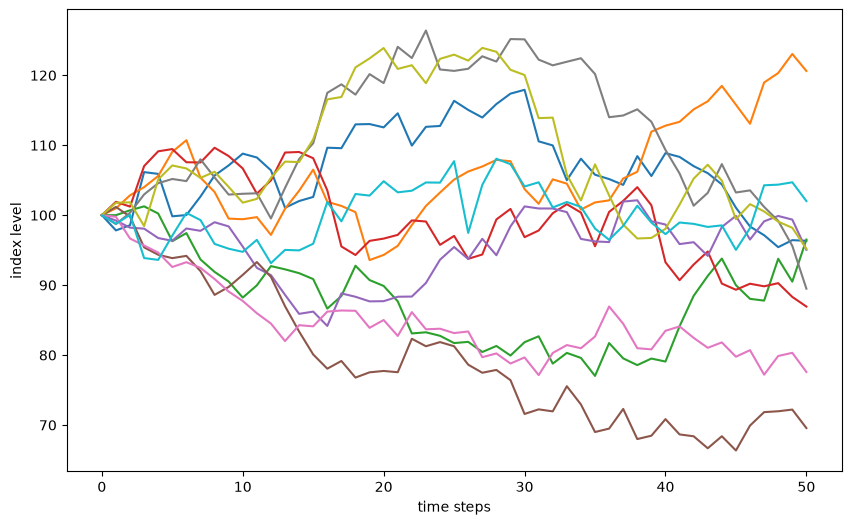

In [8]:
plt.figure(figsize=(10, 6))
plt.plot(paths[:, :10])
plt.xlabel('time steps')
plt.ylabel('index level')
plt.show()

In [9]:
paths[:, 0].round(4)

array([100.    ,  97.821 ,  98.5573, 106.1546, 105.899 ,  99.8363,
       100.0145, 102.6589, 105.6643, 107.1107, 108.7943, 108.2449,
       106.4105, 101.0575, 102.0197, 102.6052, 109.6419, 109.5725,
       112.9766, 113.0225, 112.5476, 114.5585, 109.942 , 112.6271,
       112.7502, 116.3453, 115.0443, 113.9586, 115.8831, 117.3705,
       117.9185, 110.5539, 109.9687, 104.9957, 108.0679, 105.7822,
       105.1585, 104.3304, 108.4387, 105.5963, 108.866 , 108.3284,
       107.0077, 106.0034, 104.3964, 101.0637,  98.3776,  97.135 ,
        95.4254,  96.4271,  96.3386])

In [10]:
log_returns = np.log(paths[1:] / paths[:-1])

In [11]:
log_returns[:, 0].round(4)

array([-0.022 ,  0.0075,  0.0743, -0.0024, -0.059 ,  0.0018,  0.0261,
        0.0289,  0.0136,  0.0156, -0.0051, -0.0171, -0.0516,  0.0095,
        0.0057,  0.0663, -0.0006,  0.0306,  0.0004, -0.0042,  0.0177,
       -0.0411,  0.0241,  0.0011,  0.0314, -0.0112, -0.0095,  0.0167,
        0.0128,  0.0047, -0.0645, -0.0053, -0.0463,  0.0288, -0.0214,
       -0.0059, -0.0079,  0.0386, -0.0266,  0.0305, -0.0049, -0.0123,
       -0.0094, -0.0153, -0.0324, -0.0269, -0.0127, -0.0178,  0.0104,
       -0.0009])

`scipy.stats.describe()`

In [12]:
def print_statistics(array):
    ''' 선택한 통계를 출력

    인수
    ==========
    array: ndarray
        통계를 생성할 대상 객체
    '''

    sta = scs.describe(array)
    print(f'{'statistic':^14s} | {'value':^15s}')
    print(15 * '-' + '|' + 16 * '-')
    print(f'{'size':14s} | {sta[0]:15.5f}')
    print(f'{'min':14s} | {sta[1][0]:15.5f}')
    print(f'{'max':14s} | {sta[1][1]:15.5f}')
    print(f'{'mean':14s} | {sta[2]:15.5f}')
    print(f'{'std':14s} | {np.sqrt(sta[3]):15.5f}')
    print(f'{'skew':14s} | {sta[4]:15.5f}')
    print(f'{'kurtosis':14s} | {sta[5]:15.5f}')

In [13]:
print_statistics(log_returns.flatten())

  statistic    |      value     
---------------|----------------
size           |  12500000.00000
min            |        -0.15664
max            |         0.15371
mean           |         0.00060
std            |         0.02828
skew           |         0.00055
kurtosis       |         0.00085


In [14]:
log_returns.mean() * M + 0.5 * sigma * sigma # 이토 항 수정 후의 연율화된 평균 로그 수익률

np.float64(0.05000000000000004)

In [15]:
log_returns.std() * math.sqrt(M) # 연율화된 변동성. 로그 수익률의 연율화된 표준편차

np.float64(0.2)

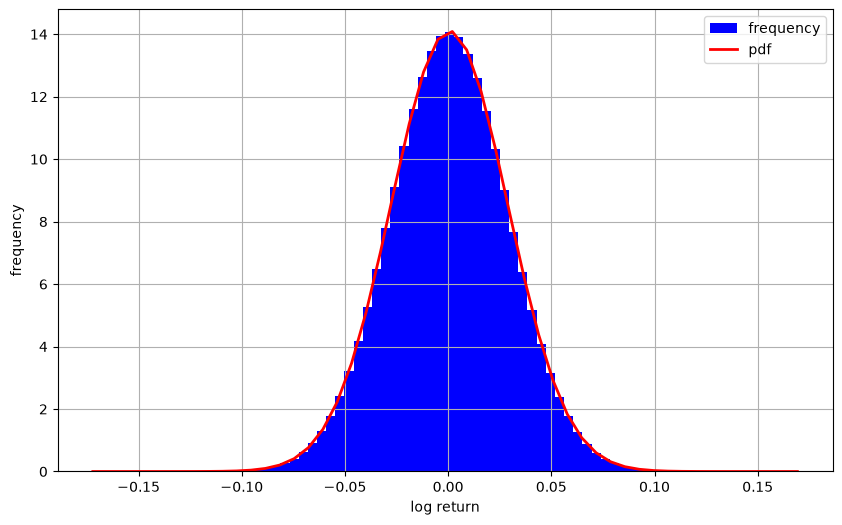

In [16]:
plt.figure(figsize=(10, 6))

plt.hist(log_returns.flatten(), bins=70, density=True, label='frequency', color='b')
plt.xlabel('log return')
plt.ylabel('frequency')

x = np.linspace(plt.axis()[0], plt.axis()[1])
plt.plot(x, scs.norm.pdf(x, loc=(r - 0.5 * sigma * sigma) / M, scale=sigma / np.sqrt(M)), 'r', lw=2.0, label='pdf')

plt.legend()
plt.grid()
plt.show()

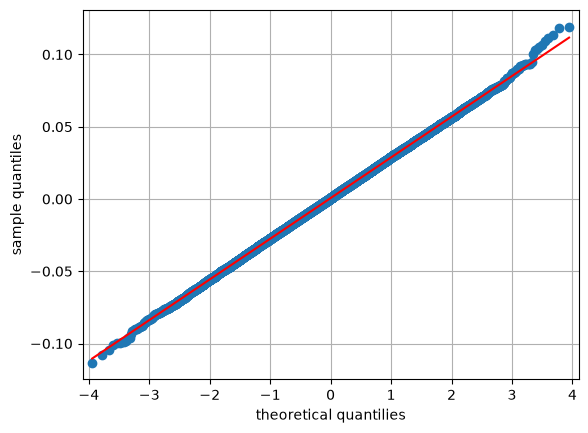

In [17]:
sm.qqplot(log_returns.flatten()[::500], line='s')

plt.xlabel('theoretical quantilies')
plt.ylabel('sample quantiles')

plt.grid()
plt.show()

`normality_test()`는 세 가지 통계적 검정 결과를 보임:

- 왜도 검정(`scipy.stats.skewtest()`): 샘플 데이터의 왜도가 정규분포와 일치하는지(0에 가까운 값을 가지는지) 판단.

- 첨도 검정(`scipy.stats.kurtosistest()`): 샘플 데이터의 첨도가 정규분포와 일치하는지(0에 가까운 값을 가지는지) 판단. 

- 정규성 검정(`scipy.stats.normaltest()`): 다른 두 검정 방법을 조합하여 정규성 검정.

In [18]:
def normality_tests(arr):
    ''' 주어진 데이터 분포의 정규성 검정

    인수
    ==========
    array: ndarray
        통계를 생성할 대상 전체
    '''

    print(f'Skew of data set  {scs.skew(arr):>14.3f}')
    print(f'Skew test p-value {scs.skewtest(arr)[1]:>14.3f}')
    print(f'Kurt of data set  {scs.kurtosis(arr):>14.3f}')
    print(f'Kurt test p-value {scs.kurtosistest(arr)[1]:>14.3f}')
    print(f'Norm test p-value {scs.normaltest(arr)[1]:>14.3f}')

In [19]:
normality_tests(log_returns.flatten())

Skew of data set           0.001
Skew test p-value          0.430
Kurt of data set           0.001
Kurt test p-value          0.541
Norm test p-value          0.607


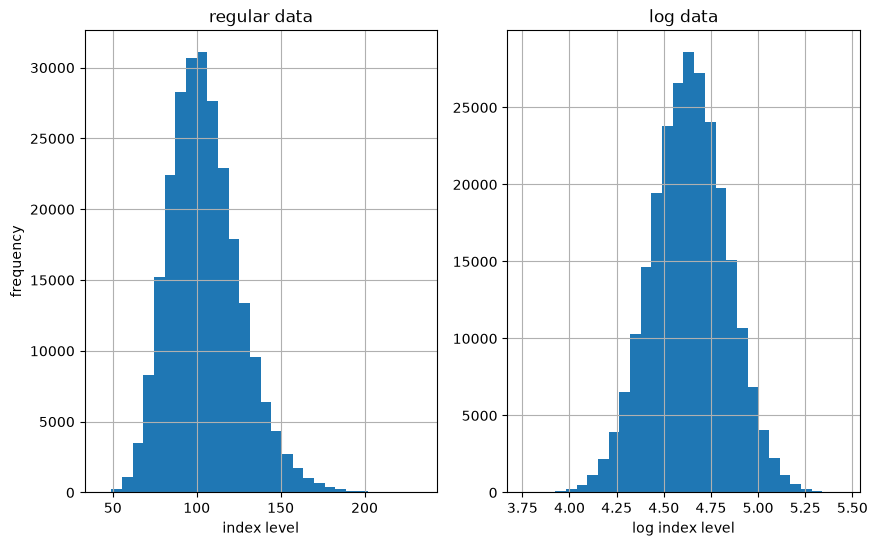

In [20]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6))

ax1.hist(paths[-1], bins=30)
ax1.set_xlabel('index level')
ax1.set_ylabel('frequency')
ax1.set_title('regular data')
ax1.grid()

ax2.hist(np.log(paths[-1]), bins=30)
ax2.set_xlabel('log index level')
ax2.set_title('log data')
ax2.grid()

plt.show()

In [21]:
print_statistics(paths[-1])

  statistic    |      value     
---------------|----------------
size           |    250000.00000
min            |        42.74870
max            |       233.58435
mean           |       105.12645
std            |        21.23174
skew           |         0.61116
kurtosis       |         0.65182


In [22]:
print_statistics(np.log(paths[-1]))

  statistic    |      value     
---------------|----------------
size           |    250000.00000
min            |         3.75534
max            |         5.45354
mean           |         4.63517
std            |         0.19998
skew           |        -0.00092
kurtosis       |        -0.00327


In [23]:
normality_tests(np.log(paths[-1]))

Skew of data set          -0.001
Skew test p-value          0.851
Kurt of data set          -0.003
Kurt test p-value          0.744
Norm test p-value          0.931


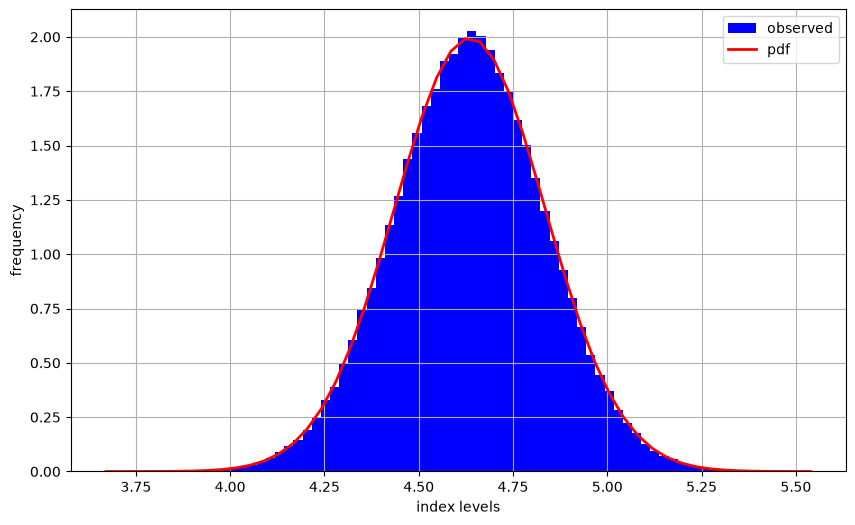

In [24]:
plt.figure(figsize=(10, 6))

log_data = np.log(paths[-1])

plt.hist(log_data, bins=70, density=True, label='observed', color='b')
plt.xlabel('index levels')
plt.ylabel('frequency')

x = np.linspace(plt.axis()[0], plt.axis()[1])
plt.plot(x, scs.norm.pdf(x, log_data.mean(), log_data.std()), 'r', lw=2.0, label='pdf')

plt.legend()
plt.grid()
plt.show()

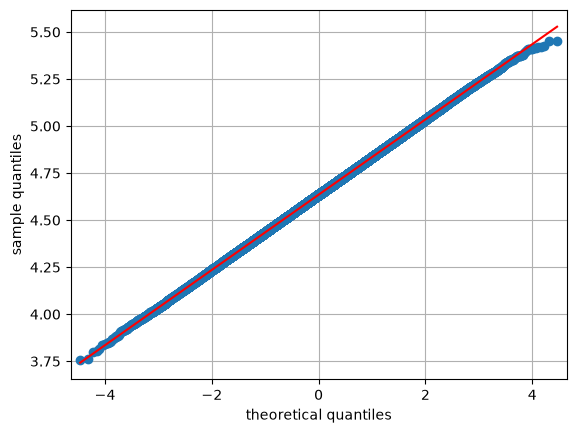

In [25]:
sm.qqplot(log_data, line='s')
plt.xlabel('theoretical quantiles')
plt.ylabel('sample quantiles')
plt.grid()
plt.show()

### 13.1.2 현실 자료 분석

- AAPL.O: 애플 주가

- MSFT.O: 마이크로소프트 주가

- SPY: SPDR S&P 500 ETF 주가

- GLD: SPDR Gold ETF 주가

In [26]:
import pandas as pd

In [27]:
raw = pd.read_csv('../source/tr_eikon_eod_data.csv', index_col=0, parse_dates=True).dropna()

In [28]:
symbols = ['SPY', 'GLD', 'AAPL.O', 'MSFT.O']

In [29]:
data = raw[symbols]
data = data.dropna()

In [30]:
data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2138 entries, 2010-01-04 to 2018-06-29
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SPY     2138 non-null   float64
 1   GLD     2138 non-null   float64
 2   AAPL.O  2138 non-null   float64
 3   MSFT.O  2138 non-null   float64
dtypes: float64(4)
memory usage: 83.5 KB


In [31]:
data.head()

,SPY,GLD,AAPL.O,MSFT.O
Date,,,,
2010-01-04,113.33,109.80,30.572827,30.950
2010-01-05,113.63,109.70,30.625684,30.960
2010-01-06,113.71,111.51,30.138541,30.770
2010-01-07,114.19,110.82,30.082827,30.452
2010-01-08,114.57,111.37,30.282827,30.660


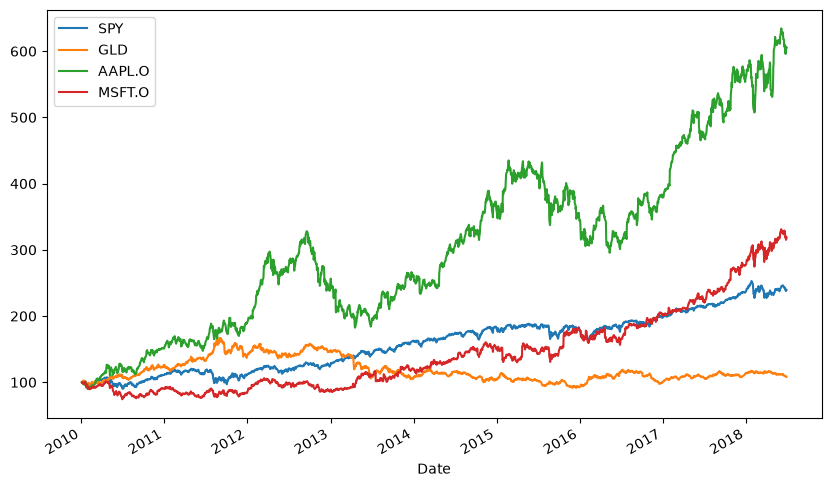

In [32]:
(data / data.iloc[0] * 100).plot(figsize=(10, 6))
plt.show()

In [33]:
log_returns = np.log(data).diff()
log_returns.head()

,SPY,GLD,AAPL.O,MSFT.O
Date,,,,
2010-01-04,NaN,NaN,NaN,NaN
2010-01-05,0.002644,-0.000911,0.001727,0.000323
2010-01-06,0.000704,0.016365,-0.016034,-0.006156
2010-01-07,0.004212,-0.006207,-0.001850,-0.010389
2010-01-08,0.003322,0.004951,0.006626,0.006807


array([[<Axes: title={'center': 'SPY'}>, <Axes: title={'center': 'GLD'}>],
       [<Axes: title={'center': 'AAPL.O'}>,
        <Axes: title={'center': 'MSFT.O'}>]], dtype=object)

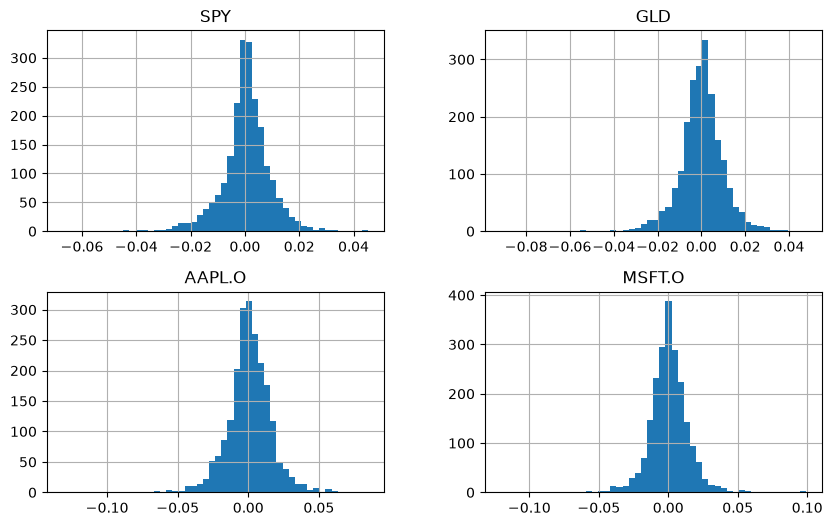

In [34]:
log_returns.hist(bins=50, figsize=(10, 6))

In [35]:
for sym in symbols:
    print(f'\nResults for symbol {sym}')
    print(30 * '-')
    log_data = np.array(log_returns[sym].dropna())
    print_statistics(log_data)


Results for symbol SPY
------------------------------
  statistic    |      value     
---------------|----------------
size           |      2137.00000
min            |        -0.06734
max            |         0.04545
mean           |         0.00041
std            |         0.00933
skew           |        -0.52189
kurtosis       |         4.52432

Results for symbol GLD
------------------------------
  statistic    |      value     
---------------|----------------
size           |      2137.00000
min            |        -0.09191
max            |         0.04795
mean           |         0.00004
std            |         0.01020
skew           |        -0.59934
kurtosis       |         5.68423

Results for symbol AAPL.O
------------------------------
  statistic    |      value     
---------------|----------------
size           |      2137.00000
min            |        -0.13187
max            |         0.08502
mean           |         0.00084
std            |         0.01591
skew   

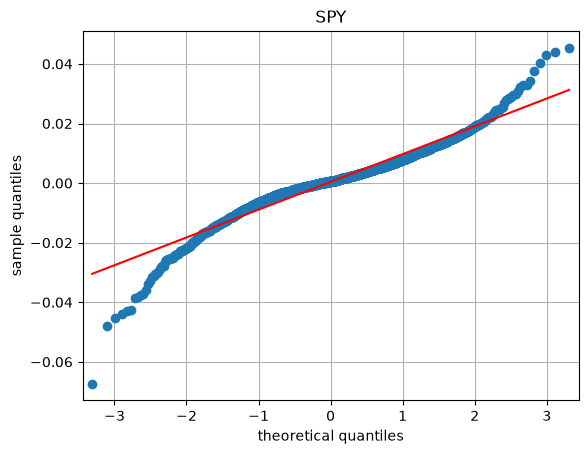

In [36]:
sm.qqplot(log_returns['SPY'].dropna(), line='s')
plt.title('SPY')
plt.xlabel('theoretical quantiles')
plt.ylabel('sample quantiles')
plt.grid()

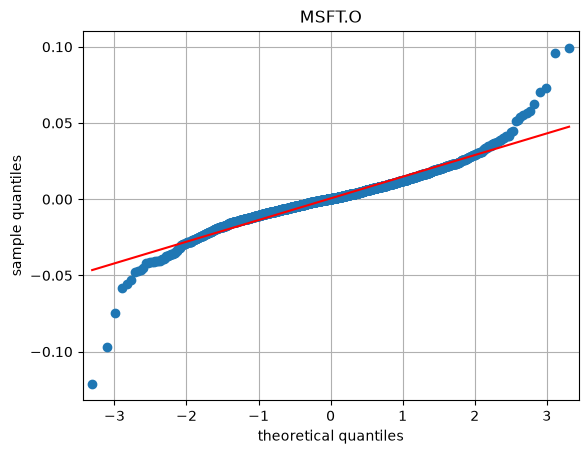

In [37]:
sm.qqplot(log_returns['MSFT.O'].dropna(), line='s')
plt.title('MSFT.O')
plt.xlabel('theoretical quantiles')
plt.ylabel('sample quantiles')
plt.grid()

In [38]:
for sym in symbols:
    print(f'\nResults for symbol {sym}')
    print(32 * '-')
    log_data = np.array(log_returns[sym].dropna())
    normality_tests(log_data)


Results for symbol SPY
--------------------------------
Skew of data set          -0.522
Skew test p-value          0.000
Kurt of data set           4.524
Kurt test p-value          0.000
Norm test p-value          0.000

Results for symbol GLD
--------------------------------
Skew of data set          -0.599
Skew test p-value          0.000
Kurt of data set           5.684
Kurt test p-value          0.000
Norm test p-value          0.000

Results for symbol AAPL.O
--------------------------------
Skew of data set          -0.235
Skew test p-value          0.000
Kurt of data set           4.790
Kurt test p-value          0.000
Norm test p-value          0.000

Results for symbol MSFT.O
--------------------------------
Skew of data set          -0.091
Skew test p-value          0.085
Kurt of data set           7.291
Kurt test p-value          0.000
Norm test p-value          0.000


## 13.2 포트폴리오 최적화

현대 포트폴리오 이론, 수익률의 정규분포 가정, 평균과 분산.

### 13.2.1 자료 분석

현대 포트폴리오 이론의 기본 아이디어: 

- 목표 수익률이 주어졌을 때 포트폴리오 위험을 최소화하거나, 

- 일정 위험이 주어졌을 때 포트폴리오 수익률을 극대화하기 위해

- **보유 주식을 분산 (distribution)하는 것.**

In [39]:
symbols = ['AAPL.O', 'MSFT.O', 'SPY', 'GLD']

In [40]:
noa = len(symbols)

In [41]:
data = raw[symbols]

In [42]:
rets = np.log(data).diff()

array([[<Axes: title={'center': 'AAPL.O'}>,
        <Axes: title={'center': 'MSFT.O'}>],
       [<Axes: title={'center': 'SPY'}>, <Axes: title={'center': 'GLD'}>]],
      dtype=object)

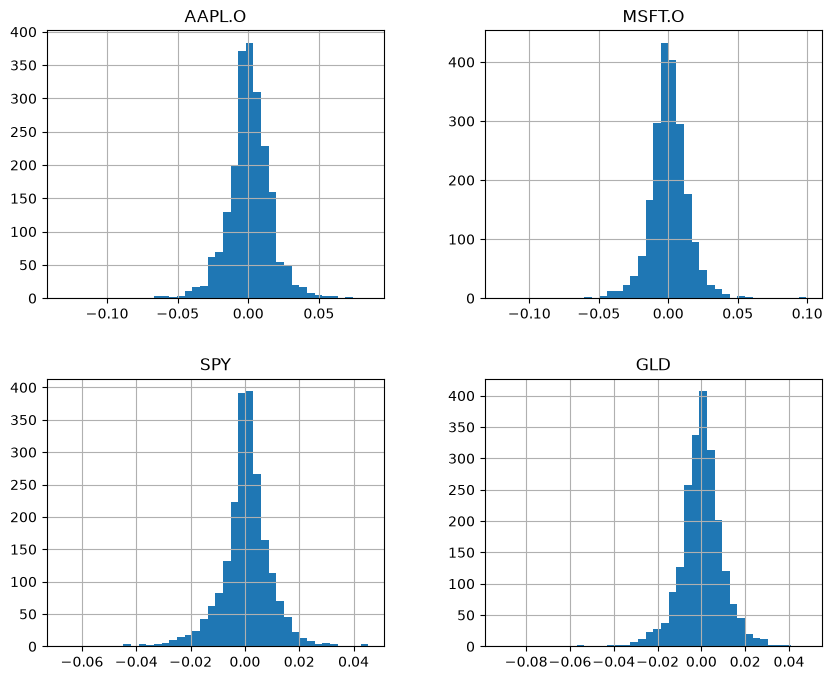

In [43]:
rets.hist(bins=40, figsize=(10, 8))

In [44]:
rets.mean()

AAPL.O    0.000843
MSFT.O    0.000542
SPY       0.000408
GLD       0.000036
dtype: float64

In [45]:
rets.mean() * 252 # 연율화된 평균 수익률

AAPL.O    0.212359
MSFT.O    0.136648
SPY       0.102928
GLD       0.009141
dtype: float64

In [46]:
rets.cov() * 252 # 연율화된 평균 수익률

,AAPL.O,MSFT.O,SPY,GLD
AAPL.O,0.063773,0.023427,0.021039,0.001513
MSFT.O,0.023427,0.050917,0.022244,-0.000347
SPY,0.021039,0.022244,0.021939,0.000062
GLD,0.001513,-0.000347,0.000062,0.026209


### 13.2.2 기초 이론

투자자가 매도 포지션을 가질 수 없고 매수 모지션만 가진다고 가정.

0과 1 사이의 난수를 네 개 생성한 후 이들의 합이 1이 되도록 정규화

In [47]:
weights = np.random.random(noa) # 무작위 포트폴리오 비중
weights /= weights.sum() # 1(100%)로 정규화``

In [48]:
weights

array([0.07650728, 0.06021919, 0.63364218, 0.22963135])

In [49]:
weights.sum()

np.float64(1.0)

**전체 포트폴리오 수익률 기댓값**

$\mu_p = E \left( \sum\limits_I w_i r_i \right) = \sum\limits_I w_i E(r_i) = \sum\limits_I w_i \mu_i = w^T \mu$

과거 평균 수익률이 미래의 기대 수익률에 대한 최선의 예측이라는 가정하에 계산된 값.

- $r_i$는 정규분포를 이룬다고 가정한 미래의 수익률(벡터)이고, 

- $\mu_i$는 각 자산의 기대 수익률

- $w^T$는 비중 벡터의 전치행렬, $\mu$는 기대 수익률 벡터

In [50]:
# 연율화된 포트폴리오 수익률 - 날짜별 포트폴리오 수익률의 평균

(np.sum(weights * rets.dropna(), axis=1)).mean() * 252

np.float64(0.09179459482057781)

In [51]:
# 연율화된 포트폴리오 수익률 - 행렬곱으로 날짜별 포트폴리오 수익률 생성 후 평균

(rets.dropna() @ weights).mean() * 252

np.float64(0.09179459482057781)

In [52]:
# 연율화된 포트폴리오 수익률 - 자산별 평균수익률의 가중합

np.sum(weights * rets.mean()) * 252

np.float64(0.09179459482057781)

In [53]:
# 연율화된 포트폴리오 수익률 - 행렬식

weights.T @ rets.mean() * 252

np.float64(0.09179459482057781)

**포트폴리오의 분산의 기댓값**

두 증권 사이의 공분산: $\sigma_{ij} = \sigma_{ji} = E(r_i - \mu_i)(r_j - \mu_j)$

단일 증권의 공분산: $\sigma_i^2 = E \left( (r_i - \mu_i)^2 \right)$

포트폴리오 공분산행렬: 

$\Sigma = \begin{bmatrix} 
\sigma_{1}^2 & \sigma_{12} & \cdots & \sigma_{1I} \\ 
\sigma_{21} & \sigma_{2}^2 & \cdots & \sigma_{2I} \\ 
\vdots & \vdots & \ddots & \vdots \\ 
\sigma_{I1} & \sigma_{I2} & \cdots & \sigma_{I}^2 
\end{bmatrix}$

포트폴리오 공분산행렬이 있으면 포트폴리오 분산의 기댓값 공식을 얻을 수 있음.

$\sigma_p^2 = E \left( (r - \mu)^2 \right) = \sum\limits_{i \in I} \sum\limits_{j \in J} w_i w_j \sigma_{ij} = w^T \Sigma w$

In [54]:
port_rets = rets.dropna() @ weights # 날짜별 포트폴리오 수익률

In [55]:
# 연율화된 포트폴리오 분산 - 프토폴리오 수익률을 직접 분산 계산

port_rets.var() * 252

np.float64(0.014763288666485533)

In [56]:
# 연율화된 포트폴리오 분산 - 평균 이탈값의 제곱합

((port_rets - port_rets.mean()) ** 2).sum() / (len(port_rets) - 1) * 252

np.float64(0.014763288666485533)

In [57]:
# 연율화된 포트폴리오 분산 - 이중합

cov_matrix = rets.dropna().cov() * 252

port_var = 0.0

for i in range(len(weights)):
    for j in range(len(weights)):
        port_var += weights[i] * weights[j] * cov_matrix.iloc[i, j]

port_var

np.float64(0.014763288666485528)

In [58]:
 # 연율화된 포트폴리오 분산 - 행렬식

weights.T @ rets.cov() * 252 @ weights

np.float64(0.01476328866648553)

In [59]:
math.sqrt(weights.T @ rets.cov() * 252 @ weights) # 연율화된 포트폴리오 변동

0.12150427427249434

포트폴리오 비중의 몬테카를로 시뮬레이션

In [60]:
def port_ret(weights):
    return np.sum(rets.mean() * weights) * 252

In [61]:
def port_vol(weights):
    return np.sqrt(weights.T @ rets.cov() * 252 @ weights)

In [62]:
prets = []
pvols = []
for p in range(2500):
    weights = np.random.random(noa)
    weights /= weights.sum()
    prets.append(port_ret(weights))
    pvols.append(port_vol(weights))
prets = np.array(prets)
pvols = np.array(pvols)

**샤프 지수**(Sharpe ratio)

- $SR \equiv \dfrac{\mu_p - r_f}{\sigma_p}$

    - 무위험 단기 이자율에 대한 포트폴리오의 초과 수익률 기댓값을 포트폴리오의 표준편차 기댓값으로 나눈 값

    - 단순화를 위해 $r_f \equiv 0$이라고 가정.

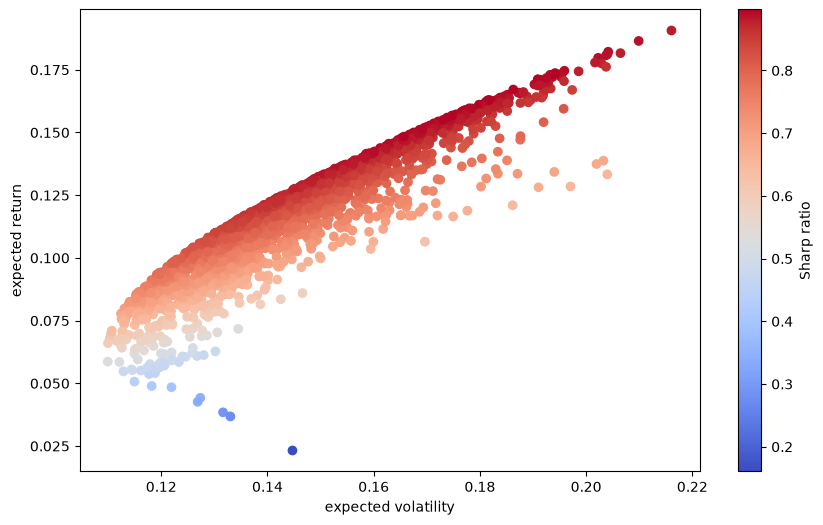

In [63]:
plt.figure(figsize=(10, 6))
plt.scatter(pvols, prets, c=prets / pvols, marker='o', cmap='coolwarm')
plt.xlabel('expected volatility')
plt.ylabel('expected return')
plt.colorbar(label='Sharp ratio')

같은 위험 수준에 대해 최대 수익률을 가지거나, 같은 수익률에 대해 최소 위험 수준을 가지는 것.

**효율적 투자선**(efficient frontier)

### 13.2.3 포트폴리오 최적화

최적 포트폴리오 계산은 제약 조건하에서의 최적화 문제이므로

`scipy.optimize` 라이브러리의

`scipy.optimize.minimize(fun, x0, method=None, bounds=None, constraints=())` 함수를 사용.

(부)등호 제약 조건과 변수 범위 제약 조건이 있는 일반적인 경우에 대해 최소화 문제를 계산

샤프 지수 최대화

- 샤프 지수의 음숫값을 최소화

- 제약 조건으로는 모든 입력 변수(주식 비중)의 합이 1

- 주식 비중에 해당하는 입력값의 범위는 0과 1 사이로 제한하여 튜플의 튜플 형태로 입력

- 초깃값 리스트는 단순하게 균등 배분

In [64]:
import scipy.optimize as sco

In [65]:
def min_func_sharpe(weights):
    return - port_ret(weights) / port_vol(weights) # 최소화할 함수

In [66]:
cons = {'type': 'eq', 'fun': lambda x: np.sum(x) - 1} # 등식 제한 조건

In [67]:
bnds = tuple((0, 1) for x in range(noa)) # 인수 범위값

In [68]:
eweights = np.array(noa * [1. / noa, ]) # 균등 비중
eweights

array([0.25, 0.25, 0.25, 0.25])

In [69]:
min_func_sharpe(eweights)

np.float64(-0.8436203363155413)

In [70]:
%%time
opts = sco.minimize(min_func_sharpe, eweights, method='SLSQP', bounds=bnds, constraints=cons) # 최적화

CPU times: user 7.09 ms, sys: 681 μs, total: 7.77 ms
Wall time: 7.28 ms


In [71]:
opts # 최적화 결과

     message: Optimization terminated successfully
     success: True
      status: 0
         fun: -0.8976673894071259
           x: [ 5.119e-01  1.913e-01  2.545e-01  4.228e-02]
         nit: 6
         jac: [ 8.968e-05  8.303e-05 -2.460e-04  1.927e-05]
        nfev: 30
        njev: 6
 multipliers: [-1.854e-05]

In [72]:
opts['x'].round(3) # 최적 포트폴리오 비중

array([0.512, 0.191, 0.255, 0.042])

In [73]:
port_ret(opts['x']).round(3) # 최적 포트폴리오 수익률

np.float64(0.161)

In [74]:
port_vol(opts['x']).round(3) # 최적 포트폴리오 변동성

np.float64(0.18)

In [75]:
port_ret(opts['x']) / port_vol(opts['x']) # 최대 샤프 지수

np.float64(0.8976673894071259)

포트폴리오 분산을 최소화

변동성을 최소화

In [76]:
optv = sco.minimize(port_vol, eweights, method='SLSQP', bounds=bnds, constraints=cons) # 포트폴리오 변동성 최소화

In [77]:
optv

     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 0.10942155263429477
           x: [ 0.000e+00  1.062e-03  5.433e-01  4.557e-01]
         nit: 9
         jac: [ 1.110e-01  1.095e-01  1.094e-01  1.094e-01]
        nfev: 45
        njev: 9
 multipliers: [ 1.094e-01]

In [78]:
optv['x'].round(3)

array([0.   , 0.001, 0.543, 0.456])

In [79]:
port_vol(optv['x']).round(3)

np.float64(0.109)

In [80]:
port_ret(optv['x']).round(3)

np.float64(0.06)

In [81]:
port_ret(optv['x']) / port_vol(optv['x'])

np.float64(0.5504173676262378)

**최소 분산**(minimum volatility) 혹은 **최소 변동성 포트폴리오**(minimum variance portfolio)

### 13.2.4 효율적 투자선

최적 포트폴리오 집합 (목표 수익률 수준에 대해 최소 변동성을 가지는 모든 포트폴리오 혹은 목표 위험 수준에 대해 최대 수익률을 가지는 모든 포트폴리오):

앞의 최적화 방법 + 여러 개의 초기 조건을 가지고 반복

목표 수익률을 고정시키고 그 수익률을 달성하면서 최소의 변동성을 가지는 포트폴리오 비중을 계산하는 것.

최적화의 제약 조건은 두 가지:

- 목표 수익률 수준이 `trets`의 값이어야 하고,

- 포트폴리오 비중의 합은 1이 되어야 함.

각 비중 변수의 범위 제한은 이전과 같음.

여러 가지 수익률값을 바꿔가면서 작업을 반복.

루프 내에서 제한 조건을 변경

In [82]:
cons = ({'type': 'eq', 'fun': lambda x: port_ret(x) - tret},
        {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}) # 효율적 투자선 제약 조건 2개

In [83]:
bnds = tuple((0, 1) for x in weights)

In [84]:
%%time
trets = np.linspace(0.05, 0.2, 50)
tvols = []
for tret in trets:
    res = sco.minimize(port_vol, eweights, method='SLSQP', bounds=bnds, constraints=cons) # 다양한 목표 수익률에 대해 포트폴리오 변동성 최소화
    tvols.append(res['fun'])
tvols = np.array(tvols)

CPU times: user 367 ms, sys: 2.32 ms, total: 369 ms
Wall time: 369 ms


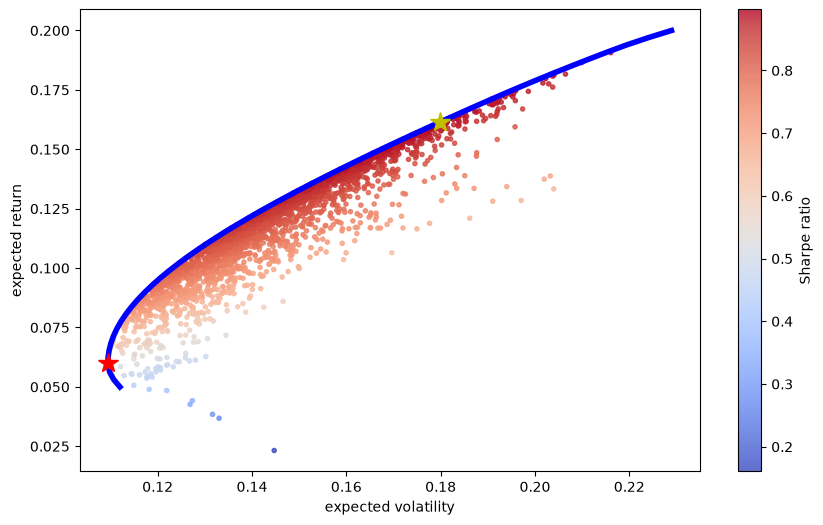

In [85]:
plt.figure(figsize=(10, 6))

# 다양한 무작위 포트폴리오 비중에 대한 수익률과 변동성의 기댓값
plt.scatter(pvols, prets, c=prets / pvols, marker='.', alpha=0.8, cmap='coolwarm')

# 특정 수익률 목표에 대한 최적 포트폴리오
plt.plot(tvols, trets, 'b', lw=4.0)

# 최대 샤프 지수를 가진 포트폴리오
plt.plot(port_vol(opts['x']), port_ret(opts['x']), 'y*', markersize=15.0)

# 최소 변동성/분산 포트폴리오
plt.plot(port_vol(optv['x']), port_ret(optv['x']), 'r*', markersize=15.0)

plt.xlabel('expected volatility')
plt.ylabel('expected return')
plt.colorbar(label='Sharpe ratio')

**효율적 투자선 (efficient frontier)**: 

- 모든 최소 분산 포트폴리오보다 수익률이 높은 모든 최적 포트폴리오들로 구성.

- 특정한 위험 수준에 대해 가장 높은 수익률, 기댓값을 가짐.

### 13.2.5 자본시장선

**현금**(cash) 혹은 **현금 계정**(cash account)과 같은 무위험 자산을 같이 고려하면, 투자자가 선택할 수 있는 효율적 투자 기회 집합은 크게 늘어남.

기본 아이디어: 

- 우선 위험 자산으로 구성된 효율적 포트폴리오를 결정한 다음 무위험 자산을 추가

- 전체 자산에서 무위험 자산에 투자된 비중을 조정하면

- 무위험 자산과 포트폴리오 사이에 직선으로 나타나는 위험-수익률 집합 중 하나를 선택할 수 있음.

수많은 효율적 포트폴리오 중에서 어떤 포트폴리오를 선택해야 최적의 투자를 할 수 있을까?

: 무위험 자산의 위험-수익률을 지나면서 효율적 투자선에 접하는 접선에 있는 포트폴리오.

위험-수익률 공간에서 점 $(\sigma_f, r_f) = (0, 무위험 이자율)$을 지나면서 효율적 투자선에 접하는 접선에 포함된 포트폴리오

이를 계산하기 위해서는 효율적 투자선의 함수 형태 근사와 1차 도함수가 필요.

**큐빅 스플라인 보간법**(cubic spline interpolation) - 구별 가능한 함수 근사치를 제공

In [86]:
import scipy.interpolate as sci

In [87]:
ind = np.argmin(tvols) # 최소 변동성 포트폴리오의 인덱스
evols = tvols[ind:] # 해당 포트폴리오의 변동성
erets = trets[ind:] # 해당 포트폴리오의 수익률

In [88]:
tck = sci.splrep(evols, erets) # 큐빅 스플라인 보간

In [89]:
def f(x):
    '''효율적 투자선 함수 (스플라인 근사)'''
    return sci.splev(x, tck, der=0)
def df(x):
    '''효율적 투자선의 1차 도함수'''
    return sci.splev(x, tck, der=1)

위험-수익률 공간에서 무위험 자산을 지나면서 효율적 투자선에 접하는 직선을 묘사하는 함수:

$t(x) = a + b \cdot x$

$
\begin{aligned}
&t(0) = r_f    &\quad \Leftrightarrow \quad &a = r_f \\
&t(x) = f(x)   &\quad \Leftrightarrow \quad &a + b \cdot x = f(x) \\
&t'(x) = f'(x) &\quad \Leftrightarrow \quad &b = f'(x)
\end{aligned}
$

효율적 투자선이나 그 도함수에 대한 닫힌 형태의 수식이 없기 때문에 연립방정식도 수치적으로 풀 수밖에 없음.

이를 풀기 위해 입력 변수 $p - (a, b, x)$가 주어지면 세 개의 값을 모두 출력하는 파이썬 함수를 정의.

`scipy.optimize` 라이브러리의 `scipy.optimize.fsolve()`함수와 `equations()`함수에 들어갈 초기 입력 변수가 있으면 연립방적식을 풀 수 있음. 

최적화의 성공 여부가 초기 입력 변수에 의존하기 때문에 초기 입력 변수는 신중하게 골라야 함.

일반적으로 초기 입력 변수는 시행착오와 추측을 조합하여 결정.

In [90]:
def equations(p, rf=0.01): # 자본시장선 수식
    a, b, x = p
    eq1 = rf - a
    eq2 = a + b * x - f(x)
    eq3 = b - df(x)
    return eq1, eq2, eq3

In [91]:
opt = sco.fsolve(equations, [0.01, 0.5, 0.15]) # 주어진 초기 조건으로 수식 계산

In [92]:
opt # 최적 인숫값

array([0.01      , 0.84470952, 0.19525392])

In [93]:
np.round(equations(opt), 6) # 방정식 결과가 0

array([ 0.,  0., -0.])

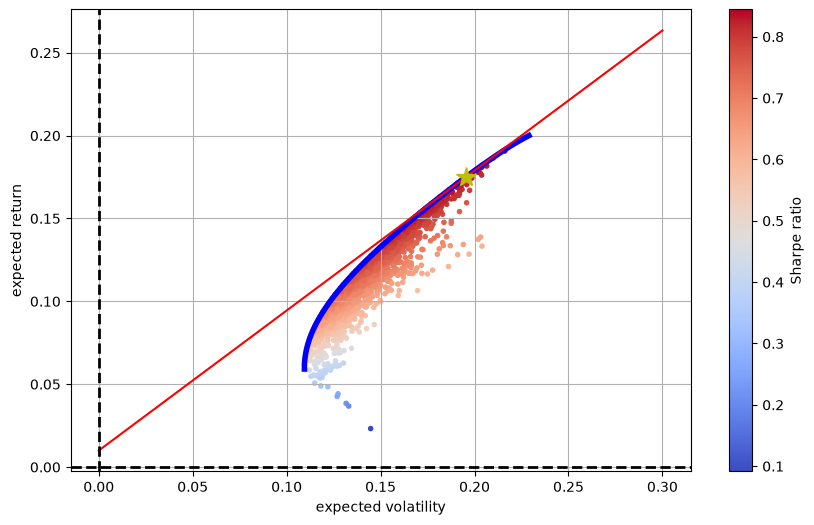

In [94]:
plt.figure(figsize=(10, 6))

# 다양한 무작위 포트폴리오 비중에 대한 수익률과 변동성의 기댓값
plt.scatter(pvols, prets, c=(prets - 0.01) / pvols, marker='.', cmap='coolwarm')

# 효율적 투자선 (efficient frontier)
plt.plot(evols, erets, 'b', lw=4.0)

# 자본시장선
cx = np.linspace(0.0, 0.3)
plt.plot(cx, opt[0] + opt[1] * cx, 'r', lw=1.5)

# 자본시장선에 접하는 최적 포트폴리오
plt.plot(opt[2], f(opt[2]), 'y*', markersize=15.0)

plt.grid(True)

plt.axhline(0, color='k', ls='--', lw=2.0)
plt.axvline(0, color='k', ls='--', lw=2.0)

plt.xlabel('expected volatility')
plt.ylabel('expected return')
plt.colorbar(label='Sharpe ratio')

무위험 이자율이 1%일 때의 자본시장선과 이에 접하는 포트폴리오(별 표시)

(자본시장선에 접하는) 최적 포트폴리오의 비중:

In [95]:
cons = ({'type': 'eq', 'fun': lambda x: port_ret(x) - f(opt[2])},
        {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}) # 접하는 포트폴리오에 대한 제한 조건
res = sco.minimize(port_vol, eweights, method='SLSQP', bounds=bnds, constraints=cons)

In [96]:
res['x'].round(3) # 해당 포트폴리오 비중

array([0.59 , 0.221, 0.189, 0.   ])

In [97]:
port_ret(res['x'])

np.float64(0.1749328429726989)

In [98]:
port_vol(res['x'])

np.float64(0.19525371969343575)

In [99]:
port_ret(res['x']) / port_vol(res['x'])

np.float64(0.8959257895181598)